<a href="https://colab.research.google.com/github/iurikistenmacker/Laborat-rio/blob/main/IV_Resistance.py" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tensão		Resistência		deltaR
-2.0		1.28		0.12
-1.9		1.40		0.12
-1.8		1.52		0.12
-1.7		1.64		0.13
-1.6		1.77		0.14
-1.5		1.91		0.16
-1.4		2.06		0.18
-1.3		2.24		0.22
-1.2		2.46		0.27
-1.1		2.73		0.36
-1.0		3.09		0.50
-0.9		3.59		0.79
-0.8		4.38		1.48
-0.7		5.86		4.12
-0.6		9.98		98.80
-0.5		108.78		-117.08
-0.4		-8.30		5.24
-0.3		-3.06		1.69
-0.2		-1.37		0.85
-0.1		-0.52		0.52
0.0		0.00		0.36
0.1		0.36		0.26
0.2		0.62		0.21
0.3		0.83		0.17
0.4		0.99		0.14
0.5		1.13		0.12
0.6		1.26		0.11
0.7		1.36		0.09
0.8		1.46		0.09
0.9		1.54		0.08
1.0		1.62		0.07
1.1		1.70		0.07
1.2		1.76		0.07
1.3		1.83		0.06
1.4		1.89		0.05
1.5		1.94		0.04
1.6		1.99		0.03
1.7		2.02		0.02
1.8		2.04		0.01
1.9		2.05		-0.00


Text(0, 0.5, 'Electric Current (nA)')

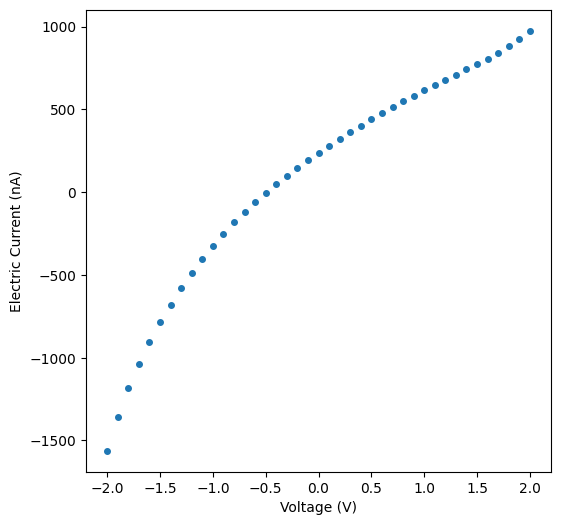

In [30]:
from pathlib import Path
from posixpath import sep
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from itertools import zip_longest

def load_data(path):
    df = pd.read_csv(path, sep="\t")
    Voltage = df["E /V"].values
    Col_I = [c for c in df.columns if c.startswith("I /pA")]
    Current = df[Col_I].mean(axis=1).values
    return Voltage, Current

def resistance():
    Voltage, Current = load_data(path)
    R = (Voltage/Current)*10**12
    return R

def linear ():
    R = resistance()
    dif = []
    for i in range(1, len(R)):
        difference = R[i] - R[i-1]
        dif.append(difference)
    return np.array(dif)


path = "/content/m1-040526_GO_IV_59% RH.txt"

Volt, Current_59_pA = load_data(path)
Current_59_nA = Current_59_pA/1000

Res = resistance()
Res_MO = Res/1000000

difRes = linear()
difRes_MO = difRes/1000000


print(f'Tensão\t\tResistência\t\tdeltaR')
for a, b, c in zip(Volt, Res_MO, difRes_MO):
    print(f'{a}\t\t{b:.2f}\t\t{c:.2f}')

df = pd.DataFrame(list(zip_longest(Volt, Res_MO, difRes_MO)), columns=['Tensão_V', 'Resistência_MOhm', 'delta R_MOhm'])
df.to_csv('dados_resistencia.txt', sep='\t')



plt.figure(figsize=(6, 6))
plt.plot(Volt, Current_59_nA, 'o', ms=4)
plt.xlabel("Voltage (V)")
plt.ylabel("Electric Current (nA)")




